# Superstore Sales Workflow Tutorial

This notebook walks through cleaning the Superstore dataset, designing a relational structure, creating an SQLite database, and running example SQL queries and visualizations.

In [44]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

## 1️) Load and Inspect the Dataset

In [45]:
# reading error codes + research is how you can learn if there is different encoding, as seen below
df = pd.read_csv('../data/Superstore.csv', encoding='ISO-8859-1')
df.head()
#df.columns

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Double check some datatypes, and for nulls and duplicates:

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

This data is incredibly clean - we can see there are no null values and no duplicates. However, there are some dates that could be saved in a better format.

## 2) Data Cleaning

In [49]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [50]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [51]:
df.Segment.unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [52]:
df.rename(columns={"Segment":"customer_category"}, inplace=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,customer_category,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


With real data, it is very likely more cleaning and wrangling would be required. 

## 3) Build Relational Tables

In [53]:
conn = sqlite3.connect('../data/superstore.db')

customers_df = df[['Customer ID','Customer Name','customer_category','City','State','Region', 'Postal Code']].drop_duplicates().rename(columns={
    'Customer ID':'customer_id',
    'Customer Name':'customer_name',
    'City':'city',
    'State':'state',
    'Region':'region',
    'Postal Code': 'zipcode'
})

products_df = df[['Product ID','Category','Sub-Category','Product Name']].drop_duplicates().rename(columns={
    'Product ID':'product_id',
    'Category':'category',
    'Sub-Category':'subcategory',
    'Product Name':'product_name'
})

orders_df = df[['Order ID','Order Date','Ship Date','Ship Mode','Customer ID']].drop_duplicates().rename(columns={
    'Order ID':'order_id',
    'Order Date':'order_date',
    'Ship Date':'ship_date',
    'Ship Mode':'ship_mode',
    'Customer ID':'customer_id'
})

order_details_df = df[['Order ID','Product ID','Sales','Quantity','Discount','Profit']].rename(columns={
    'Order ID':'order_id',
    'Product ID':'product_id'
    #'Sales': 'sales',
    #'Quantity':'quantity',
    #'Discount':'discount',
    #'Profit':'profit'
})


customers_df.to_sql('customers', conn, index=False, if_exists='replace')
products_df.to_sql('products', conn, index=False, if_exists='replace')
orders_df.to_sql('orders', conn, index=False, if_exists='replace')
order_details_df.to_sql('order_details', conn, index=False, if_exists='replace')
conn.commit()

In [55]:
for name, df in [
    ('customers', customers_df),
    ("products", products_df),
    ("orders", orders_df),
    ("order_details", order_details_df)
]:
    df.to_csv(f'../data/{name}.csv')

## 4) Make Some Queries!

### Which customer segments bring in the most revenue and profit?

In [56]:
query1 = """ SELECT 
    c.customer_category,
    ROUND(SUM(od.sales), 2) AS total_sales,
    ROUND(SUM(od.profit), 2) AS total_profit
FROM order_details od
JOIN orders o ON od.order_id = o.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_category
ORDER BY total_sales DESC;
"""
result1 = pd.read_sql(query1, conn)
result1

,customer_category,total_sales,total_profit
0,Consumer,8380282.43,973085.86
1,Corporate,5044899.83,660287.69
2,Home Office,2964459.36,434344.01


### What are the top 10 customers by total sales?

In [57]:
query2 = """ select 
             cu.customer_id, 
             cu.customer_name ,
             sum(od.sales) as total_sales
             from customers cu
             join orders o on o.customer_id = cu.customer_id
             join order_details od on od.order_id = o.order_id
             group by cu.customer_id
             order by total_sales desc
             limit 10; 
             """
result2 = pd.read_sql(query2, conn)
result2

,customer_id,customer_name,total_sales
0,KL-16645,Ken Lonsdale,155927.519
1,SE-20110,Sanjit Engle,134303.818
2,CL-12565,Clay Ludtke,130566.552
3,AB-10105,Adrian Barton,130262.139
4,SC-20095,Sanjit Chand,127281.006
5,SM-20320,Sean Miller,125215.250
6,EH-13765,Edward Hooks,123730.560
7,GT-14710,Greg Tran,118201.200
8,SV-20365,Seth Vernon,114709.500
9,JL-15835,John Lee,107799.153


### Which product categories and subcategories are the most profitable overall?

In [58]:
query3 = """ select 
             p.category, 
             p.subcategory,
             round(sum (od.profit),2) as most_profitable
             from products p
             left join order_details od on od.product_id = p.product_id
             group by p.category, p.subcategory
             order by most_profitable desc; """
result3 = pd.read_sql(query3, conn)
result3

,category,subcategory,most_profitable
0,Technology,Copiers,55617.82
1,Technology,Accessories,48359.05
2,Technology,Phones,46936.19
3,Office Supplies,Paper,36994.53
4,Office Supplies,Binders,30373.20
5,Furniture,Chairs,26707.65
6,Office Supplies,Storage,21408.70
7,Office Supplies,Appliances,18514.49
8,Furniture,Furnishings,14569.59
9,Office Supplies,Envelopes,6964.18


### What is the average discount given per category?

In [59]:
query4 = """ select 
         p.category,
         round (avg(od.discount), 2) as average_discount
         from order_details od
         join products p on p.product_id = od.product_id
         group by p.category
         order by average_discount; """
result4 = pd.read_sql(query4, conn)
result4

,category,average_discount
0,Technology,0.13
1,Office Supplies,0.16
2,Furniture,0.17


### Which states or regions contribute the most to total sales?

In [60]:
query5 = """ select 
             cu.state, 
             round(sum(od.sales),2) as total_sales
             from customers cu 
             left join  orders o on cu.customer_id = o.customer_id
             left join  order_details od on od.order_id= o.order_id
             group by cu.state; """
result5 = pd.read_sql(query5, conn)
result5

,state,total_sales
0,Alabama,143041.01
1,Arizona,332928.15
2,Arkansas,95158.70
3,California,3314837.69
4,Colorado,254680.96
5,Connecticut,128414.01
6,Delaware,175340.88
7,District of Columbia,15420.31
8,Florida,635637.78
9,Georgia,267895.57


### How many orders were shipped late (where Ship Date > Order Date + 3 days)?

In [61]:
query6 = """ select 
             od.order_id,
             sum(od.sales) as total_sales, 
             SUBSTR(order_date, 7, 4) AS year
             from orders o
             join order_details od on o.order_id = od.order_id
             group by year
             order by total_sales desc; """
result6 = pd.read_sql(query6, conn)
result6

,order_id,total_sales,year
0,CA-2014-129567,31009.7960,3-18
1,CA-2013-154508,28143.4040,1-17
2,CA-2014-126074,25008.8950,0-03
3,US-2012-168935,24417.1405,1-27
4,CA-2013-113817,24096.3210,1-08
...,...,...,...
302,CA-2014-155558,1022.1880,0-27
303,CA-2013-158568,988.8960,8-30
304,CA-2011-133690,960.5780,8-03
305,CA-2011-123260,728.7980,8-26


### Which month or year had the highest total sales?

In [62]:
query7 = """ select 
             od.order_id,
             sum(od.sales) as total_sales, 
             SUBSTR(order_date, 7, 4) AS year
             from orders o
             join order_details od on o.order_id = od.order_id
             group by year
             order by total_sales desc; """
result7 = pd.read_sql(query7, conn)
result7

,order_id,total_sales,year
0,CA-2014-129567,31009.7960,3-18
1,CA-2013-154508,28143.4040,1-17
2,CA-2014-126074,25008.8950,0-03
3,US-2012-168935,24417.1405,1-27
4,CA-2013-113817,24096.3210,1-08
...,...,...,...
302,CA-2014-155558,1022.1880,0-27
303,CA-2013-158568,988.8960,8-30
304,CA-2011-133690,960.5780,8-03
305,CA-2011-123260,728.7980,8-26


### What are the most frequently ordered products?

In [63]:
query8 = """ SELECT 
    p.product_name,
    SUM(od.quantity) AS unidades_totales_vendidas
FROM order_details od
JOIN products p ON od.product_id = p.product_id
GROUP BY p.product_id, p.product_name
ORDER BY unidades_totales_vendidas DESC
LIMIT 5; """
result8 = pd.read_sql(query8, conn)
result8

,product_name,unidades_totales_vendidas
0,Imation 16GB Mini TravelDrive USB 2.0 Flash Drive,75
1,Logitech P710e Mobile Speakerphone,75
2,Xerox 1881,70
3,Xerox 1908,70
4,GBC Premium Transparent Covers with Diagonal L...,67


### Which customers placed more than 5 orders total?

In [64]:
query9 = """ SELECT 
    c.customer_id,
    c.customer_name,
    COUNT(o.order_id) AS total_orders
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.customer_id, c.customer_name
HAVING COUNT(o.order_id) > 5
ORDER BY total_orders DESC; """
result9 = pd.read_sql(query9, conn)
result9

,customer_id,customer_name,total_orders
0,EP-13915,Emily Phan,289
1,EA-14035,Erin Ashbrook,169
2,JE-15745,Joel Eaton,169
3,SH-19975,Sally Hughsby,169
4,ZC-21910,Zuschuss Carroll,169
...,...,...,...
742,SS-20515,Shirley Schmidt,9
743,SW-20350,Sean Wendt,9
744,TM-21490,Tony Molinari,9
745,TT-21265,Tim Taslimi,9


### What’s the profit margin (profit ÷ sales) by category or segment?

In [65]:
query10 = """ SELECT 
    p.category,
    c.customer_category                                  AS segment,
    ROUND(SUM(od.Sales), 2)                              AS total_sales,
    ROUND(SUM(od.Profit), 2)                             AS total_profit,
    ROUND(SUM(od.Profit) / SUM(od.Sales) * 100, 2)      AS profit_margin_pct
FROM order_details od
JOIN products p   ON od.product_id  = p.product_id
JOIN orders o     ON od.order_id    = o.order_id
JOIN customers c  ON o.customer_id  = c.customer_id
GROUP BY p.category, c.customer_category
ORDER BY p.category, profit_margin_pct DESC; """
result10 = pd.read_sql(query10, conn)
result10

,category,segment,total_sales,total_profit,profit_margin_pct
0,Furniture,Corporate,1647140.29,59737.03,3.63
1,Furniture,Home Office,861032.79,24383.79,2.83
2,Furniture,Consumer,3049686.72,76983.98,2.52
3,Office Supplies,Home Office,919219.72,208675.28,22.70
4,Office Supplies,Corporate,1757108.81,295830.49,16.84
5,Office Supplies,Consumer,2677126.04,419514.88,15.67
6,Technology,Corporate,1798529.15,325555.97,18.10
7,Technology,Home Office,1342732.39,231782.75,17.26
8,Technology,Consumer,3062352.56,526444.86,17.19


### 5) Visualize it!

From your ten results, select at least 4 to utilize in a meaningful visualization. 

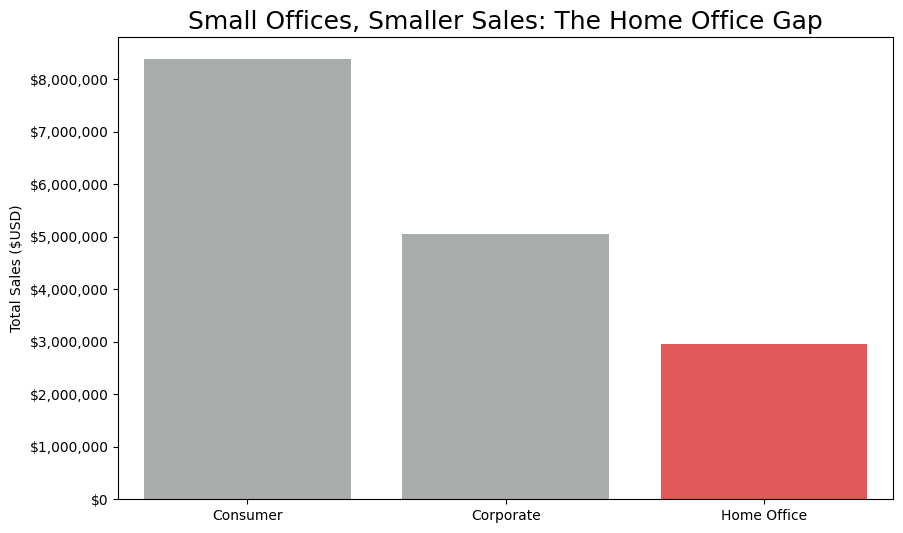

In [66]:
# example using result1
plt.figure(figsize=(10,6))
colors = ["#a7adaa", "#a7adaa", "#f74141" ]
sns.barplot(result1, x='customer_category', y='total_sales', palette=colors, hue='customer_category', legend=False)
plt.title('Small Offices, Smaller Sales: The Home Office Gap',fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Sales ($USD)')

#for those wondering how to get rid of scientific notation! Set style to plain:
plt.ticklabel_format(style='plain', axis='y')

#mticker is a great library for helping tick mark formatting, such as adding commas and dollar signs in this case
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
# fig, axes = plt.subplots(2, 2, figsize=(18, 12))
# fig.suptitle('Superstore Sales & Profit Analysis', fontsize=22, fontweight='bold', y=1.01)

# # Paletas
# palette_cat   = ["#f74141", "#a7adaa", "#a7adaa"]
# palette_seg   = ["#a7adaa", "#a7adaa", "#f74141"]
# palette_green = ["#2ecc71", "#a7adaa", "#e74c3c"]


# #using the seaborn library, despining is way easier!
# sns.despine()
# plt.show()


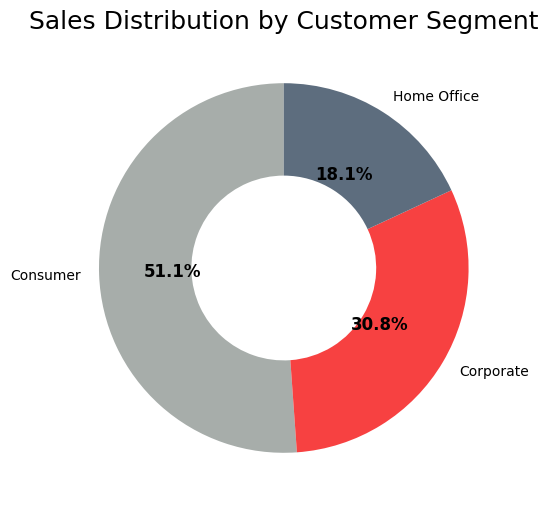

In [69]:
# visualization four code here

plt.figure(figsize=(10, 6))

wedge_colors = ["#a7adaa", "#f74141", "#5d6d7e"]
wedges, texts, autotexts = plt.pie(
    result1['total_sales'],
    labels=result1['customer_category'],
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=90,
    wedgeprops=dict(width=0.5)   # <-- esto lo convierte en donut
)
for text in autotexts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

plt.title('Sales Distribution by Customer Segment', fontsize=18)
plt.savefig("../images/img_pie.png")
plt.show()

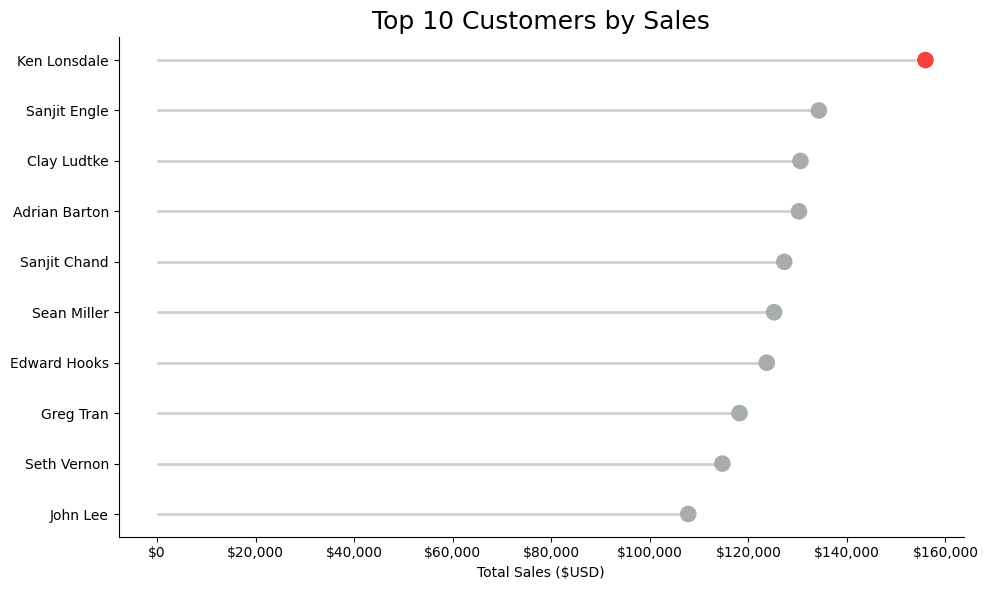

In [70]:
# visualization four code here

plt.figure(figsize=(10, 6))

result2_top = result2.head(10).sort_values('total_sales')
colors = ["#f74141" if i == len(result2_top) - 1 else "#a7adaa"
          for i in range(len(result2_top))]

plt.hlines(y=result2_top['customer_name'], xmin=0,
           xmax=result2_top['total_sales'], color="#d0d0d0", linewidth=2)
plt.scatter(result2_top['total_sales'], result2_top['customer_name'],
            color=colors, s=120, zorder=5)

plt.title('Top 10 Customers by Sales', fontsize=18)
plt.xlabel('Total Sales ($USD)')
plt.ylabel(None)
ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
sns.despine()
plt.tight_layout()
plt.savefig("../images/img_scatter.png")
plt.show()

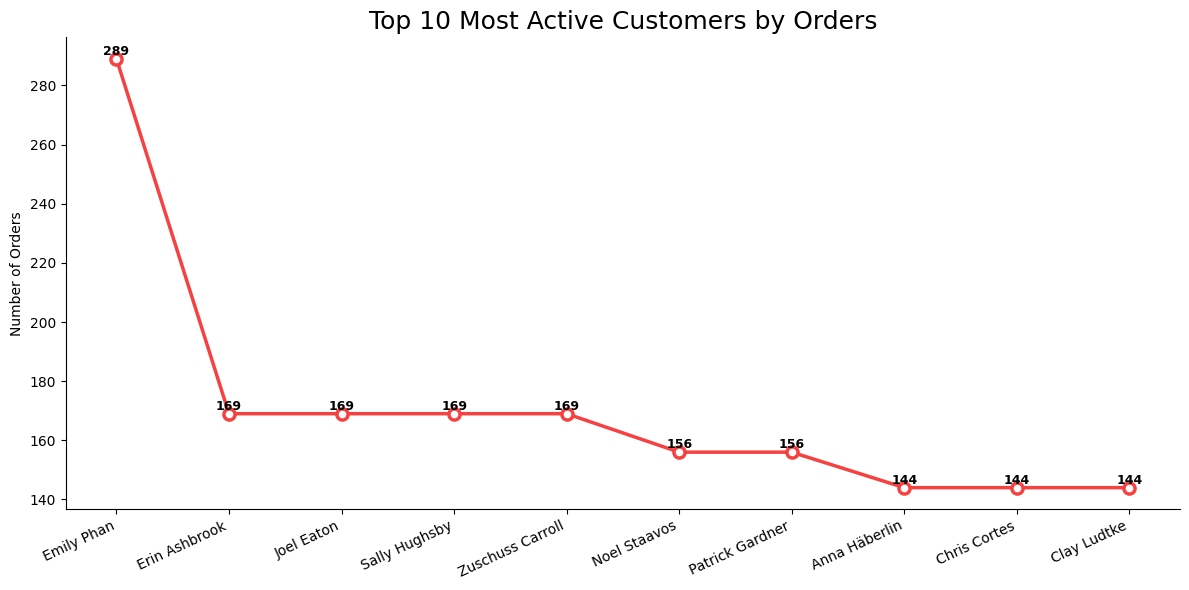

In [72]:
# visualization four code here

plt.figure(figsize=(12, 6))

result9_top = result9.head(10).sort_values('total_orders', ascending=False)

plt.plot(result9_top['customer_name'], result9_top['total_orders'],
         color='#f74141', linewidth=2.5, marker='o',
         markersize=8, markerfacecolor='white', markeredgewidth=2.5,
         markeredgecolor='#f74141')

# Etiqueta de valor encima de cada punto
for i, (name, orders) in enumerate(zip(result9_top['customer_name'],
                                        result9_top['total_orders'])):
    plt.text(i, orders + 0.3, str(orders),
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Top 10 Most Active Customers by Orders', fontsize=18)
plt.xlabel(None)
plt.ylabel('Number of Orders')
plt.xticks(rotation=25, ha='right')
sns.despine()
plt.tight_layout()
plt.savefig("../images/img_line.png")
plt.show()

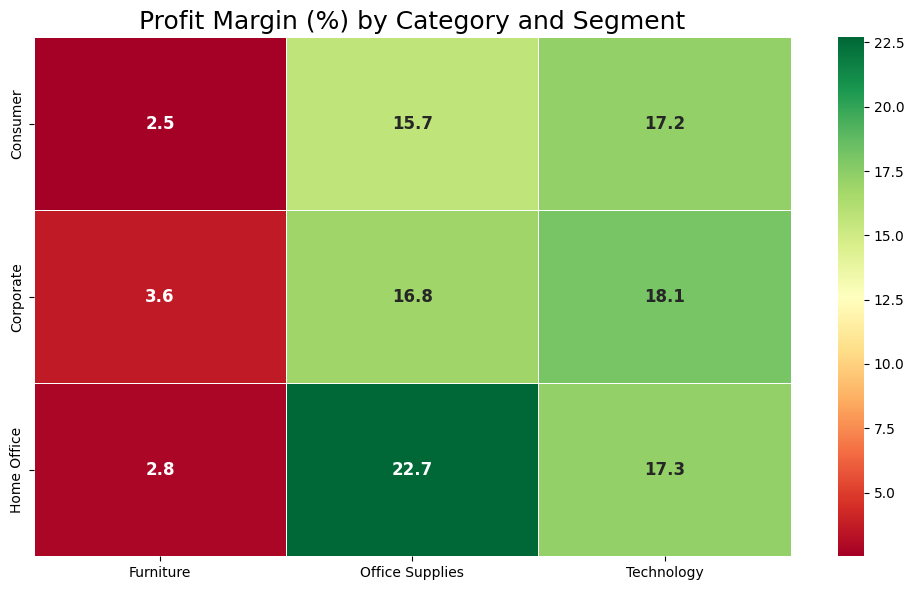

In [73]:
# visualization four code here

plt.figure(figsize=(10, 6))

# Pivot para formato de heatmap
pivot = result10.pivot(index='segment', columns='category', values='profit_margin_pct')

sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='white',
    annot_kws={"size": 12, "weight": "bold"}
)
plt.title('Profit Margin (%) by Category and Segment', fontsize=18)
plt.xlabel(None)
plt.ylabel(None)
plt.tight_layout()
plt.savefig("../images/img_heatmap.png")
plt.show()

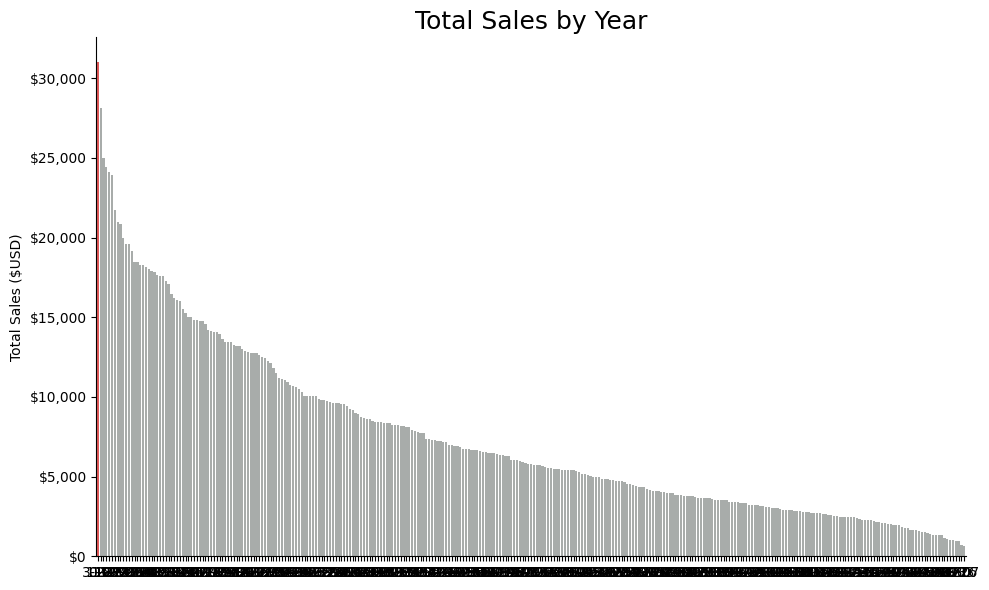

In [74]:
# visualization four code here

plt.figure(figsize=(10, 6))

colors = ["#f74141" if v == result6['total_sales'].max()
          else "#a7adaa" for v in result6['total_sales']]

sns.barplot(data=result6, x='year', y='total_sales',
            palette=colors, hue='year', legend=False)

plt.title('Total Sales by Year', fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Sales ($USD)')
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
sns.despine()
plt.tight_layout()
plt.savefig("../images/img_barplot.png")
plt.show()